## Generating plots for the Pitch Detection portion
Also justifying hyperparameters?

## The pipeline in totality

In [1]:
# autoreload when modules edited
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

from algorithms.Config import Config
from app_logic.user.ds.Recording import Recording
from app_logic.midi.ScoreData import ScoreData

# test pitch detection accuracy
AUDIO_PATH = "../resources/recordings/bach_fugue_recording.mp3"
MIDI_PATH = "../resources/scores/fugue.mid"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 2,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 21, # frame size (NOTE: should always be odd)
    'h2': 19, # hop size
    'pitch_thresh': 0.5,
    'slope_thresh': 0.75 / 21,
    'unv_ratio': 0.8, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# create MIDI data
score_data = ScoreData(filepath=MIDI_PATH)

# create USER data, computing pitches
rec = Recording(score_data=score_data, config=config)
rec.load_audio(AUDIO_PATH)
rec.detect_notes()
rec.resize(new_length=rec.get_length())

Loading score file: ../resources/scores/fugue.mid
Handling MIDI file...


100%|██████████| 4498/4498 [00:02<00:00, 1695.98it/s]


Tempo changed to 83 BPM (factor: 1.04). Score length is now 12.90 sec.


In [22]:
%gui qt

import sys
from PyQt6.QtWidgets import QApplication
from PyQt6.QtCore import QCoreApplication

sys.path.append('../')
from ui.GuitarHero import RunGuitarHero

if __name__ == '__main__':
    if not QCoreApplication.instance():
        app = QApplication(sys.argv)
    else:
        app = QCoreApplication.instance()

    vis = RunGuitarHero(recording=rec, app=app)

Loading Recording into ScorePlot...


## Pitch Detection Unpacked

In [ ]:
import numpy as np
from scipy.stats import beta
from scipy.signal import find_peaks, iirfilter, sosfilt

class PitchDetector:
    
    def __init__(self, recording: Recording):
        """
        Initialize the pitch detection parameters, like the tuning, frequency range, etc.
        Best to make it as specific as possible to your desired use case to improve accuracy of the detection.
        """
        self.recording = recording
        self.config = self.recording.config
        self.SR = self.config.sr # for sample-to-frequency conversion

        # --- pitch config variables ---
        # ensure max lag is big enough to detect lowest f0 (largest period)
        # defaults to violin min
        self.tau_max = int(self.config.sr / self.config.fmin) 
        self.tau_min = int(self.config.sr / self.config.fmax)

        # initialize beta distribution parameters
        self.UNVOICED_PROB = 0.01
        self.N_THRESHOLDS = 100
        self.beta_pdf, self.thresholds = self.threshold_prior(n_thresholds=self.N_THRESHOLDS)

        # rolling window variables (for detect_pitches)
        self.FRAME_SIZE = self.config.w1
        self.HOP_SIZE = self.config.h1

    # the probability distribution of thresholds
    def threshold_prior(self, n_thresholds: int=100, a: float=2, b: float=34/3) -> tuple[np.ndarray, np.ndarray]:
        """
        Returns a beta distribution modeling the pdf for YIN thresholds,
        represented as a numpy array of size N_THRESHOLDS corresponding to the pdf values.
        Also returns the array of thresholds.

        Possible a,b parameters from paper:
            - mean=0.1 beta(a=2, b=18)
            - mean=0.15 beta(a=2, b=11.33)
            - mean=0.2 beta(a=2, b=8)

        Not yet sure how these parameters are determined but I got them from the paper.
        """
        # all thresholds
        thresholds = np.linspace(0, 1, n_thresholds+1)
        thresholds = thresholds[1:] # remove the 0 threshold
        beta_pdf = beta.pdf(thresholds, a, b) / n_thresholds
        return beta_pdf, thresholds

    # --- frequency parsing functions ---
    # autocorrelation (base)
    def autocorrelation_fft(self, x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """
        Fast autocorrelation function implementation using Wiener-Khinchin theorem,
        which computes autocorrelation as the inverse FFT of the signal's power spectrum.

        Step 1 of Yin algorithm, corresponding to equation (1) in Cheveigne, Kawahara 2002.

        Args:
            x: The current frame of audio samples in Yin algorithm
            tau_max: Check for all time lags up to this value for in autocorrelation

        Returns:
            autocorrelation: The similarity curve.
            amplitudes: Amplitudes of the frame.
        """
        x = np.array(x, dtype=np.float64)
        w = x.size
        tau_max = min(self.tau_max, w)

        # zero-pad the audio signal array by the minimum power of 2 which
        # is larger than the window size + tau_max
        min_fft_size = w + tau_max  # (pad by >tau_max for frame end)

        p2 = (min_fft_size // 32).bit_length()
        nice_fft_sizes = (16, 18, 20, 24, 25, 27, 30, 32)
        size_pad = min(size * (2 ** p2) for size in nice_fft_sizes if size * 2 ** p2 >= min_fft_size)

        # --- AUTOCORRELATION WITH WIENER-KHINCHIN ---
        # decompose the signal into its frequency components
        fft_x = np.fft.rfft(x, size_pad)  
        psd = fft_x * fft_x.conjugate() # power spectrum density
        autocorrelation = np.fft.irfft(psd)[:tau_max] 

        amplitudes = np.abs(fft_x)

        # only return valid overlapping values up to window_size-tau_max
        return autocorrelation, amplitudes

    # modifying the difference function
    def cmndf(self, x, acf) -> np.ndarray:
        """
        cumulative normalized difference function (CMNDF) for better peak-picking of the fundamental period
        based directly off original YIN algorithm

        Args:
            x: needed to compute energy for diff_fct inversion
            acf: the result of autocorrelation on x
        """
        # --- INVERT TO DIFFERENCE FUNCTION ---
        # compute the energy (r_t(0) and r_{t+\tau}(0)) for each lag
        r_0 = np.sum(x**2)
        energy = np.full(acf.shape, r_0)

        diff_fct = energy[0] + energy - 2*acf
        diff_fct[0] = 0
        diff_fct = np.abs(diff_fct)

        # --- NORMALIZE + CLAMP
        diff_fct = diff_fct / (np.max(diff_fct) - np.min(diff_fct))

        cmndf = np.zeros(self.tau_max) 
        cmndf[0] = 1 # make first value 1
        total_diff = 1

        for tau in range(1, self.tau_max):
            total_diff += diff_fct[tau]
            avg_diff = total_diff / tau 
            cmndf[tau] = diff_fct[tau] / avg_diff

        return cmndf

    # --- peak-picking ---
    # prominence-based initial peak-finding
    def find_acf_peaks(self, acf: np.ndarray):
        """prominence-based peak picking of the autocorrelation curve
        returns the indices of all possible tau (fundamental period) values
        """
        # initial prominence as 1/2 overall acf range
        prominence = abs((np.max(acf) - np.min(acf))/2)

        n = 5 # how many times to find peaks within the intial prominence range
        for i in range(0, n):
            # try the lowest prominence we can that still returns valid
            p = prominence - prominence*(i/n) 
            acf_peaks, _ = find_peaks(acf, prominence=p)
            if len(acf_peaks) > 0:
                break

        # fallback if still empty
        if acf_peaks.size == 0:
            # look for the global ACF max in [tau_min, tau_max)
            region = acf[self.tau_min : self.tau_max]
            best = np.argmax(region) + self.tau_min
            acf_peaks = np.array([best], dtype=int)

        return acf_peaks

    # find the pitch according to YIN thresholding
    def find_pitch(self, cdf: np.ndarray, acf_peaks: np.ndarray, threshold: float=0.1) -> tuple[int, bool]:
        """
        Finds the YIN pitch estimate with their absolute thresholding step by searching for the first cdf trough
        below a certain 'absolute threshold'. Runs 

        Args:
            cdf: the clamped difference function for y-values corresponding in the threshold range
            acf_peaks: indices of the prominent-peaks found from the ACF (to index into the CDF)
            threshold: take the first trough below this value of d'(tau)
        
        Returns:
            tau_0 (int): The fundamental period estimate. If possible, the first tau st. 
                            d'(tau) < threshold. Else, the x of the global minima
            tau_idx (int): index of the chosen peak in the acf_peaks array
            is_voiced (bool): False if we return the global min
        """
        for i, min in np.ndenumerate(acf_peaks):
            if cdf[min] <= threshold:
                return min, i[0], True
        
        # no min found below threshold, return the global minima
        i = np.argmin(cdf[acf_peaks])
        global_min = acf_peaks[i]
        return global_min, i, False

    # assign remaining peaks a probability with find_pitch
    def pitch_probabilities(self, acf_peaks: np.ndarray, cdf: np.ndarray) -> tuple[np.ndarray, float]:
        """
        Given all prominent-enough peaks of the original ACF curve, 
        computes the probability of all possible period (tau) = 1/f_0 estimates.
        Based off the PYin method of probability assignment.

        Args:
            acf_peaks: indices of all prominent-enough peaks of the original ACF curve
            cdf: clamped difference function, to help for threshold-based peak-picking

        Returns:
            pitch_probs: array of same shape as acf_peaks, where corresponding
                            indices represent associated probabilities
            unvoiced_prob: 1 - sum(tau_probs), eg adding up all the times we had to 
                            take the global min because nothing was below the threshold
        """
        pitch_probs = np.zeros_like(acf_peaks, dtype=np.float64)

        for i, threshold in enumerate(self.thresholds):
            tau_0, j, is_voiced = self.find_pitch(cdf, acf_peaks, threshold)
            # if returned pitch for a threshold is not within pitch range, call it unvoiced
            # (trying to minimize harmonic errors)
            if is_voiced and tau_0 <= self.tau_max and tau_0 >= self.tau_min:
                pitch_probs[j] += self.beta_pdf[i]
            else:
                pitch_probs[j] += self.beta_pdf[i] * self.UNVOICED_PROB
            
        unvoiced_prob = 1 - np.sum(pitch_probs)
        return pitch_probs, unvoiced_prob

    # refine final peak estimates
    def parabolic_interpolation(self, acf: np.ndarray, acf_peak: int) -> float:
        """
        Refines the peak estimates by performing parabolic interpolation around the given index
        of the AACF. Fits a negative quadratic to the supplied minima.
        
        Args:
            acf: A 1D array of y-values (e.g., diff_fct values).
            acf_peak: The index of the maximum point in acf to interpolate around.

        Returns:
            The interpolated x-pos of the supplied acf_peak
        """
        x = acf_peak

        # don't interpolate at boundaries - need at least 3 points
        if x <= 0 or x >= len(acf) - 1:
            return float(x)

        y_1 = acf[x - 1]
        y_2 = acf[x]
        y_3 = acf[x + 1]

        denominator = 2 * (y_1 - 2*y_2 + y_3)
        if denominator == 0:
            return float(x)
        
        x_interpolated = x + (y_1 - y_3) / denominator
        return x_interpolated


    # AUDIO PREPROCESSING
    def bandpass_filter(self, x: np.ndarray, fmin: float=50, fmax: float=4000) -> np.ndarray:
        """
        a 2nd order Butterworth bandpass IIR (infinite impulse response) filter to get 
        rid of noise outside of the typical pitch range

        Args:
            x: The input audio signal as a 1D NumPy array.
            fmin: The lower cutoff frequency (in Hz) for the bandpass filter. Frequencies below this value will be attenuated.
            fmax: The upper cutoff frequency (in Hz) for the bandpass filter. Frequencies above this value will be attenuated.

        Returns:
            np.ndarray: The filtered audio signal as a 1D NumPy array, with reduced noise outside the typical pitch range.
        """
        sos = iirfilter(
            N=2, Wn=[fmin, fmax],
            btype='bandpass', 
            ftype='butter', 
            output='sos', 
            fs=self.SR
        )
        x = sosfilt(sos, x)
        return x

    def preprocess_audio(self, x: list) -> tuple[np.ndarray, float]:
        """
        centers the audio around mean, normalizes, 
        and applies high pass iir filter to prepare for pitch detection

        Args:
            x (list): The input audio signal as a list of samples.

        Returns:
            tuple: A tuple containing the preprocessed audio signal (as a NumPy array) and the volume (as a float).
        """
        x = np.asarray(x, dtype=float)
        # x = x.astype(float)
        x = x - np.mean(x) # center
        volume = np.sqrt(np.mean(x ** 2))  # get volume as mean |amplitude| of the x (before normalizing)
        x = x/np.max(np.abs(x)) # normalize
        x = self.bandpass_filter(x, fmin=self.config.fmin*0.8, fmax=self.config.fmax*1.2) # get rid of noise outside of pitch range
        # x = self.high_pass_iir_filter(x, iir_cutoff_freq)
        return x, volume

## Plots to see the functions

In [15]:
# test pitch detection accuracy
AUDIO_PATH = "../resources/recordings/bach_fugue_recording.mp3"
MIDI_PATH = "../resources/scores/fugue.mid"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 2,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 21, # frame size (NOTE: should always be odd)
    'h2': 19, # hop size
    'pitch_thresh': 0.5,
    'slope_thresh': 0.75 / 21,
    'unv_ratio': 0.8, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# create MIDI data
score_data = ScoreData(filepath=MIDI_PATH)

# create USER data, computing pitches
rec = Recording(score_data=score_data, config=config)
rec.load_audio(AUDIO_PATH)
pd = PitchDetector(recording=rec)

Loading score file: ../resources/scores/fugue.mid
Handling MIDI file...


100%|██████████| 4498/4498 [00:02<00:00, 1680.23it/s]


2.585966531942235
testing prominence 2.585966531942235
testing prominence 2.0687732255537883
testing prominence 1.551579919165341
testing prominence 1.0343866127768941


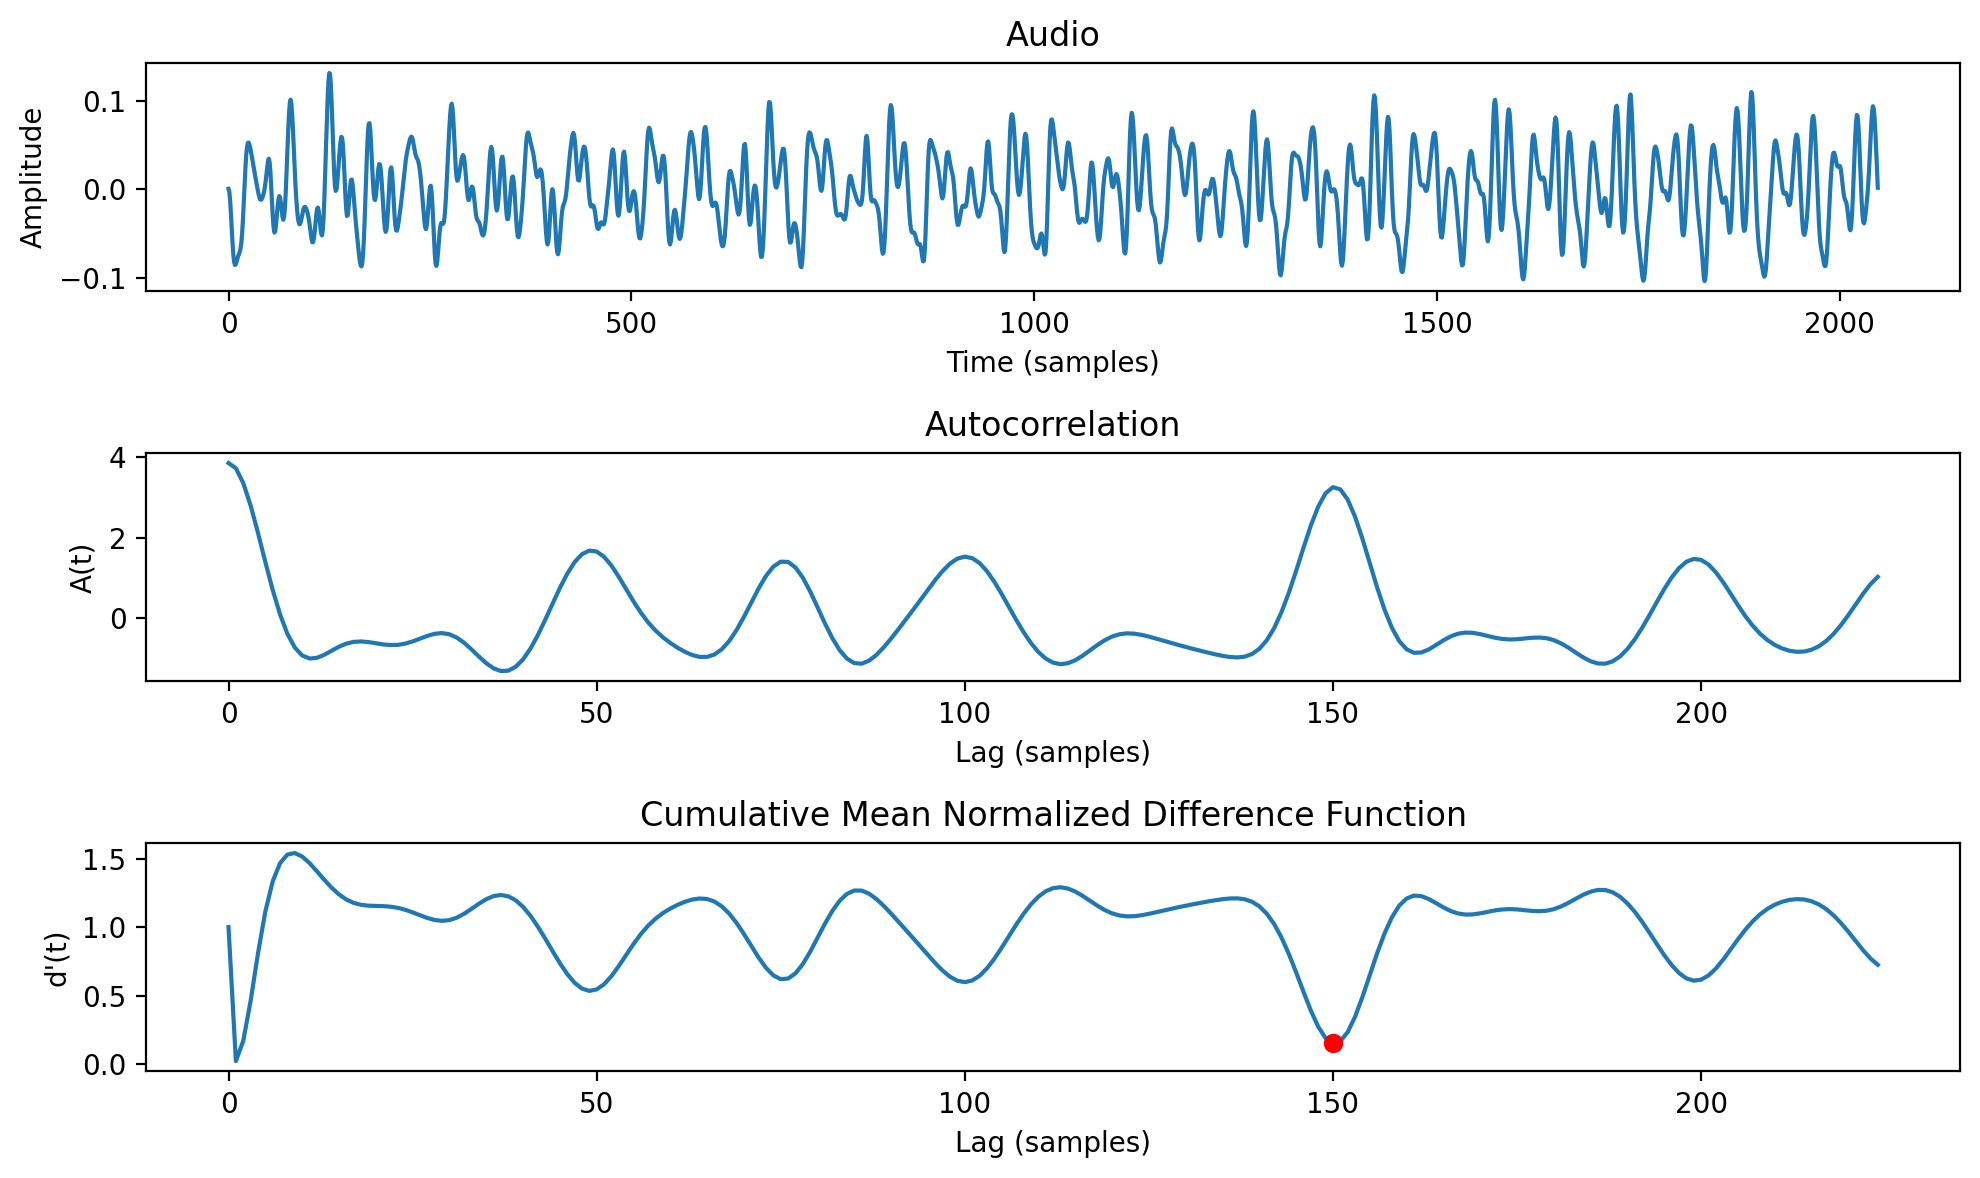

In [19]:
import sys
sys.path.append('..')

import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# convert to mono
x, vol = pd.preprocess_audio(rec.audio_data.data)

# get only the audio we want
FRAME_SIZE = 2048*2
start_idx = int(1.25 * config.sr) # 1.25 seconds in
x2 = x[start_idx:start_idx+config.w1]
acf, _ = pd.autocorrelation_fft(x2)
cmndf = pd.cmndf(x2, acf)

# prominent peak-picking
prominence = abs((np.max(acf) - np.min(acf))/2)
print(prominence)

n = 5
for i in range(0, n):
    p = prominence - prominence*(i/n)
    print(f"testing prominence {p}")
    cmndf_peaks, _ = find_peaks(-cmndf, prominence=p)
    if len(cmndf_peaks) > 0:
        break

# plot
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

axs[0].set_title("Audio")
axs[0].set_xlabel('Time (samples)')
axs[0].set_ylabel("Amplitude")
axs[0].plot(x2)

axs[1].plot(acf)
axs[1].set_xlabel('Lag (samples)')
axs[1].set_ylabel('A(t)')
axs[1].set_title("Autocorrelation")

axs[2].plot(cmndf)
axs[2].set_xlabel('Lag (samples)')
axs[2].set_ylabel("d'(t)")
axs[2].plot(cmndf_peaks, cmndf[cmndf_peaks], 'ro')
axs[2].set_title("Cumulative Mean Normalized Difference Function")

plt.tight_layout()
plt.show()